# Select Channel Subset that is sensitive to parcel subset

In [ ]:
import numpy as np
import cedalion
import cedalion.nirs
# import cedalion.imagereco.forward_model as fw
import cedalion.dot.forward_model as fw
# import cedalion.datasets
import os
import cedalion.xrutils as xrutils
# import cedalion.plots
import xarray as xr
import cedalion.geometry.landmarks as cd_landmarks
import matplotlib.pyplot as plt
import cedalion.sim.synthetic_hrf as synHRF_ced
from cedalion import units
import cedalion.dataclasses as cdc
import pyvista as pv
import cedalion.models.glm as glm
# from cedalion.imagereco.solver import pseudo_inverse_stacked
#pv.set_jupyter_backend('server') # this enables interactive plots
import cedalion.sigproc.quality as quality
from cedalion.sigproc.quality import repair_amp
import random
import pickle
# import cedalion.vis.plot_sensitivity_matrix
import cedalion.dot as dot
from cedalion.io.forward_model import load_Adot
xr.set_options(display_expand_data=False);

# import cedalion.imagereco.forward_model as fw
# from cedalion.imagereco.solver import pseudo_inverse_stacked
# import configs
# from configs import load_dataset_configs

In [ ]:
# data_path = configs.data_path_prefix
data_path = "src/subset/thomas_data/data/"

fwm = fw.ForwardModel

In [ ]:
with open(data_path + 'parcels_colin.pickle', 'rb') as f:
    parcels_colin = pickle.load(f)

with open(data_path + 'parcels_icbm.pickle', 'rb') as f:
    parcels_icbm = pickle.load(f)

laura_sens_path = os.path.join(data_path, 'BS_Laura', "BS_Laura_YY_parcel_sens_channels")
with open(laura_sens_path, 'rb') as f:
    channel_roi_sens_laura = pickle.load(f)

with open(os.path.join(data_path, 'NN22_Resting_State', "NN_22_C3_C4_close_channels"), 'rb') as f:
    c3_c4_rs = pickle.load(f)

In [ ]:
# data_type = 'BallSqueezingHD_modified'
data_type = 'BS_Laura'

In [ ]:
DATASET_NAME = data_type
data_path_prefix = f'datasets/raw/{DATASET_NAME}/'
results_path_prefix = f'results/subset/{DATASET_NAME}/'

data_path = data_path_prefix
data_path

'datasets/raw/BS_Laura/'

In [ ]:
rec = cedalion.io.read_snirf(data_path + 'sub-586' + "/nirs/" + 'sub-586' + '_task-BS_run-01_nirs.snirf')[0]
    
meas_list = rec._measurement_lists["amp"]

# both should then be equal
print(f'Number of channels in rec["amp"]: {len(set(rec["amp"].channel.values))}')
print(f'Number of channels in meas_list: {len(set(meas_list.channel.values))}')

head_icbm152 = dot.get_standard_headmodel('icbm152')  

if DATASET_NAME == "BS_Laura":
    # this is required for BU Data (Laura's)
    T = np.array([
        [-9.57882733e-01, -7.20806358e-03,  6.20193531e-03, 2.21208571e+02],
        [-2.02271710e-02,  6.03819925e-02,  9.94046165e-01, -2.03010603e+01],
        [-8.79481533e-03, -1.02761992e+00,  6.59199998e-02, 2.87749135e+02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 1.00000000e+00]])
    
    ninja_aligned = rec.geo3d.points.apply_transform(T)
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(ninja_aligned)
else:
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(rec.geo3d)
    

fwm = cedalion.dot.forward_model.ForwardModel(
    head_icbm152, 
    geo3d_snapped_ijk,
    meas_list
)
pre_processed_path = "datasets/pre_processed/BS_Laura"
fluence_fname = os.path.join(pre_processed_path, "fluence_" + DATASET_NAME + ".h5")
sensitivity_fname = os.path.join(pre_processed_path, "sensitivity_" + DATASET_NAME + ".h5")

# compute fluence and sensitivity only once
# fwm.compute_fluence_mcx(fluence_fname)
# fwm.compute_sensitivity(fluence_fname, sensitivity_fname)

Adot = load_Adot(sensitivity_fname)

# recon = dot.ImageRecon(
#     Adot,
#     recon_mode="mua2conc",
#     brain_only=True,
#     alpha_meas=10,
#     alpha_spatial=10e-3,
#     apply_c_meas=True,
#     spatial_basis_functions=None,
# )

Number of channels in rec["amp"]: 1220
Number of channels in meas_list: 1220


In [ ]:
len(rec["amp"].channel.values)

1220

In [ ]:
# if data_type == 'BS_Laura':
#     rec = cedalion.io.read_snirf(data_path + 'sub-586' + "/nirs/" + 'sub-586' + '_task-BS_run-01_nirs.snirf')[0]
#     with open(data_path + 'BS_Laura/Adot/Adot_BSLaura_ICBM.pickle', 'rb') as f:
#         Adot = pickle.load(f)
# elif data_type == 'HD_Squeezing':
#     rec = cedalion.datasets.get_fingertappingDOT()
#     with open(data_path + 'HD_Squeezing/Adot/Adot_HDSqueezing_ICBM.pickle', 'rb') as f:
#         Adot = pickle.load(f)
geo3d = rec.geo3d
amp = rec["amp"]
dists = cedalion.xrutils.norm(
    geo3d.loc[amp.source] - geo3d.loc[amp.detector],
    dim=geo3d.points.crs
)
selected_channels = list(dists.channel[dists.values < 44].values)
amp = amp.sel(channel=selected_channels)

/opt/conda/envs/cedalion/lib/python3.11/site-packages/xarray/core/variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


In [ ]:
len(selected_channels)

576

In [ ]:
dOD_thresh = 0.001
minCh = 1 
dHbO = 10 #µM 
dHbR = -3 #µM

Adot = Adot.assign_coords(parcel = ("vertex", parcels_icbm))
parcel_dOD, parcel_mask = fwm.parcel_sensitivity(Adot, None, dOD_thresh, minCh, dHbO, dHbR)
sensitive_parcels = parcel_mask.where(parcel_mask, drop=True)["parcel"].values.tolist()

In [ ]:
len(sensitive_parcels)

374

In [14]:
len(channel_roi_sens_laura)

157

In [15]:
parcel_dOD = parcel_dOD.sel(channel=selected_channels)
if data_type == 'BS_Laura':
    parcel_dOD = parcel_dOD.sel(channel=channel_roi_sens_laura)

In [16]:
len(parcel_dOD)

2

In [17]:
# dataset_configs = load_dataset_configs(data_types=['HD_Squeezing'], load_sensitivity=True)

In [18]:
with open('src/subset/mo_thomas_data/parcel_dOD_BallSqueezingHD_modified.pkl', 'rb') as f:
    parcel_dOD_bsq_hd = pickle.load(f)
    
with open('src/subset/mo_thomas_data/parcel_masks_BallSqueezingHD_modified.pkl', 'rb') as f:
    parcel_mask_bsq_hd = pickle.load(f)    

sensitive_parcels_bsq_hd = parcel_mask_bsq_hd.where(parcel_mask_bsq_hd, drop=True)["parcel"].values.tolist()  
  
len(parcel_dOD_bsq_hd), len(parcel_mask_bsq_hd), len(sensitive_parcels_bsq_hd)

(602, 602, 110)

In [19]:
# hd_sq_par = dataset_configs['HD_Squeezing'].sensitive_parcels
hd_sq_par = sensitive_parcels_bsq_hd
som_mot_a_parcels = [p for p in sensitive_parcels if 'SomMotA' in p]
len(som_mot_a_parcels)

49

In [20]:
len(hd_sq_par)

110

In [21]:
#parcel_dOD_roi_max = parcel_dOD.sel(parcel=hd_sq_par, wavelength='850').max(dim='parcel')
parcel_dOD_roi_max = parcel_dOD.sel(parcel=som_mot_a_parcels, wavelength='850').max(dim='parcel')

In [22]:
# for all-parcel-roi:
#parcel_dOD_roi_mask = (parcel_dOD_roi_max > parcel_dOD_roi_max.mean())
# for SomMotA parcels in BS_Laura
# restrictive
#parcel_dOD_roi_mask = (parcel_dOD_roi_max > 0.01)
# not so restrictive
parcel_dOD_roi_mask = (parcel_dOD_roi_max > 0.0035)

In [23]:
# example hrf roi channels 
example_hrf_roi_channels = ['S52D106', 'S51D108', 'S52D111', 'S46D105', 'S48D107', 'S46D112', 'S46D107', 'S40D19', 'S50D23', 'S53D30', 'S11D110', 'S53D21', 'S11D111', 'S53D24', 'S53D32']

In [24]:
parcel_dOD_roi_mask.sum()

<xarray.DataArray ()> Size: 8B
45
Coordinates:
    wavelength  float64 8B 850.0

In [25]:
channel_array = xr.where(parcel_dOD_roi_mask, 1, 0)
# set entries to 2 where channel is in the list
channel_array.loc[dict(channel=[ch for ch in example_hrf_roi_channels if ch in channel_array.channel.values])] = 1

In [26]:
channel_array

<xarray.DataArray (channel: 157)> Size: 1kB
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 ... 1 1 1 0 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0
Coordinates:
  * channel     (channel) object 1kB 'S6D3' 'S6D18' 'S6D20' ... 'S56D1' 'S56D18'
    wavelength  float64 8B 850.0

In [27]:
channel_array

<xarray.DataArray (channel: 157)> Size: 1kB
0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 ... 1 1 1 0 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0
Coordinates:
  * channel     (channel) object 1kB 'S6D3' 'S6D18' 'S6D20' ... 'S56D1' 'S56D18'
    wavelength  float64 8B 850.0

In [41]:
channel_array1 = channel_array[channel_array != 0]
channel_array1

<xarray.DataArray (channel: 45)> Size: 360B
1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
Coordinates:
  * channel     (channel) object 360B 'S11D83' 'S11D89' ... 'S53D30' 'S53D32'
    wavelength  float64 8B 850.0

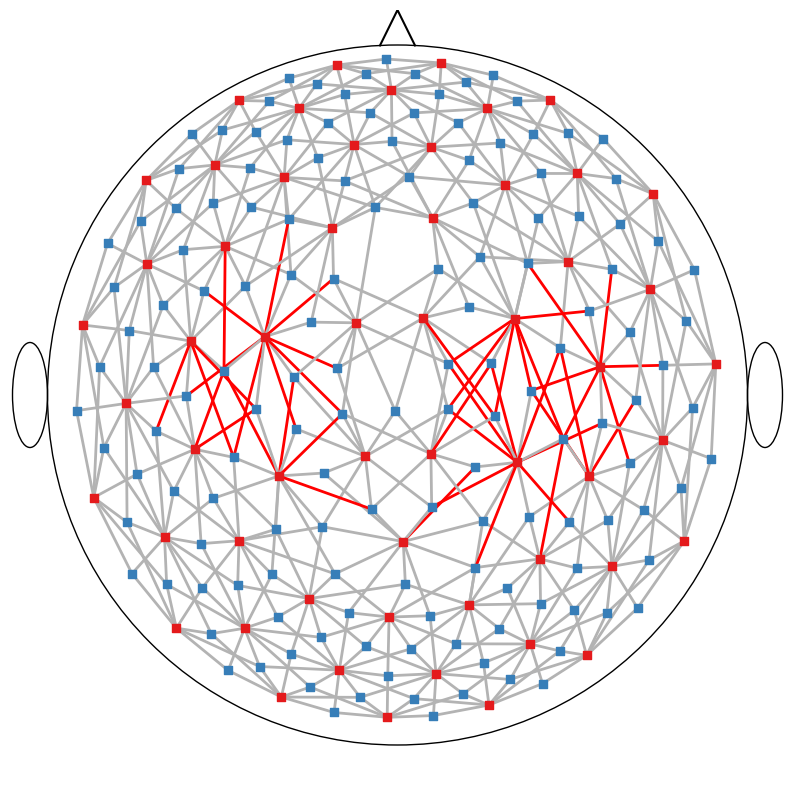

In [40]:
fig, ax = plt.subplots(1, 1)
# adjust plot size
fig.set_size_inches(10, 10)

# cedalion.plots.scalp_plot(
import cedalion.vis.anatomy.scalp_plot
cedalion.vis.anatomy.scalp_plot(    
    amp,
    geo3d,
    channel_array,
    ax,
    title="",
    vmin=0,
    vmax=1,
    cb_label="",
    add_colorbar=False,
)

In [ ]:
parcel_roi_masked_channels = list(channel_array[channel_array == 1].channel.values)

if data_type == 'BS_Laura':
    write_path = os.path.join(data_path, 'BS_Laura', "BS_Laura_SomMotA_sens_channels")
elif data_type == 'HD_Squeezing':
    write_path = os.path.join(data_path, 'HD_Squeezing', "HD_Squeezing_SomMotA_sens_channels")


#with open(write_path, 'wb') as f:
#    pickle.dump(parcel_roi_masked_channels, f)

In [22]:
# def load_dataset_configs(data_types, alpha_sp=1e-3, load_sensitivity=False, test=True):

#     dataset_configs = {}
    
#     dOD_thresh = 0.001
#     minCh = 1 
#     dHbO = 10 #µM 
#     dHbR = -3 #µM

#     # Load matrices

#     if 'Syn_Finger_Tapping' in data_types:
#         '''
#         if test:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/Finger_Tapping/test/sp_{spatial_scaling}/{subject}/int_{int_scaling}/run{run}_epochs_labels.pkl"
#             #subjects=['sub-02']
#             subjects=['sub-02', 'sub-04', 'sub-05', 'sub-06', 'sub-08', 'sub-10', 'sub-11', 'sub-13', 'sub-14', 'sub-17', 'sub-18']
#         else:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/Finger_Tapping/new/sp_{spatial_scaling}/{subject}/int_{int_scaling}/run{run}_epochs_labels.pkl"
#             subjects=['sub-02', 'sub-04', 'sub-05', 'sub-06', 'sub-08', 'sub-10', 'sub-11', 'sub-13', 'sub-14', 'sub-17', 'sub-18']

#         dataset_configs['Syn_Finger_Tapping'] = DataConfig(
#             synthetic=True,
#             all_subjects=['sub-02', 'sub-04', 'sub-05', 'sub-06', 'sub-08', 'sub-09', 'sub-10', 'sub-11', 'sub-12', 'sub-13', 'sub-14', 'sub-16', 'sub-17', 'sub-18'],
#             subjects=subjects,
#             n_runs=lambda idx: 2 if idx < 5 else 1,
#             runs = lambda subject: [0, 1] if subject in ['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08'] else [0],
#             base_path=data_path_prefix + "NN22_Resting_State/",
#             snirf_path= "Full_SynHRF_Data/Finger_Tapping/sp_{spatial_scale}/{subject}/nirs/{subject}_task-SynHRF_{run}_nirs.snirf",
#             resting_snirf_path="NN22_RS/{subject}/nirs/{subject}_task-RS_{run}_nirs.snirf",
#             clean_channels_path=lambda subject, run: f"epochs_labels/clean_channels/{subject}/{run}/clean_channels.pkl",
#             epochs_labels_path=epo_label_path,
#             feature_slices={"Slope": slice(0, 9), "Mean": slice(3, 10), "Max": slice(2, 8), "Min": slice(2,8)},
#             Adot=None,
#             B=None,
#             sensitive_parcels=None,
#             #parcel_subset={"SomMotA": [p for p in sensitive_parcels_ninja_colin_ft if p.startswith("SomMotA")]},
#             parcel_subset=None,
#             long_channels=long_channels_dict["NN22_Resting_State"],
#             probe_area=probe_area_dict['NN22_Resting_State']['active_area']
#         )
#         '''

#         if test:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/Finger_Tapping/test/sp_{spatial_scaling}/{subject}/int_{int_scaling}/run{run}_epochs_labels.pkl"
#             #subjects=['sub-586']
#             #subjects=['sub-586', 'sub-587']
#             subjects=['sub-568', 'sub-580', 'sub-581', 'sub-583', 'sub-586', 'sub-587', 'sub-592', 'sub-613', 'sub-618', 'sub-619', 'sub-621', 'sub-633', 'sub-638', 'sub-640']
#         else:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/Finger_Tapping/new/sp_{spatial_scaling}/{subject}/int_{int_scaling}/run{run}_epochs_labels.pkl"
#             subjects=['sub-568', 'sub-580', 'sub-581', 'sub-583', 'sub-586', 'sub-587', 'sub-592', 'sub-613', 'sub-618', 'sub-619', 'sub-621', 'sub-633', 'sub-638', 'sub-640']
#         dataset_configs['Syn_Finger_Tapping'] = DataConfig(
#             synthetic=True,
#             all_subjects=['sub-568', 'sub-580', 'sub-581', 'sub-583', 'sub-586', 'sub-587', 'sub-588', 'sub-592', 'sub-613', 'sub-618', 'sub-619', 'sub-621', 'sub-633', 'sub-638', 'sub-639', 'sub-640'],
#             subjects=subjects,
#             n_runs=lambda _: 1,
#             runs=lambda _: ['1'],
#             base_path=data_path_prefix + "NN22_Resting_State/",
#             snirf_path= "Full_SynHRF_Data/Finger_Tapping/sp_{spatial_scale}/{subject}/nirs/{subject}_task-SynHRF_{run}_nirs.snirf",
#             resting_snirf_path="NN22_RS/{subject}/nirs/{subject}_task-RS_run-0{run}_nirs.snirf",
#             clean_channels_path=lambda subject, run: f"epochs_labels/clean_channels/{subject}/{run+1}/clean_channels.pkl",
#             epochs_labels_path=epo_label_path,
#             feature_slices={"Slope": slice(0, 9), "Mean": slice(3, 10), "Max": slice(2, 8), "Min": slice(2,8)},
#             Adot=None,
#             B=None,
#             sensitive_parcels=None,
#             parcel_subset=None,
#             long_channels=long_channels_dict["NN22_Resting_State"],
#             probe_area=probe_area_dict['NN22_Resting_State']['active_area']
#         )

#     if 'HD_Squeezing' in data_types or 'BS_Laura' in data_types:

#         if load_sensitivity:
#             with open(data_path_prefix + 'HD_Squeezing/Adot/Adot_HDSqueezing_ICBM.pickle', 'rb') as f:
#                 Adot_HD_Squeezing = pickle.load(f)
#             #Adot_HD_Squeezing = cedalion.datasets.get_precomputed_sensitivity('fingertappingDOT', head_model='icbm152')
#             Adot_HD_Squeezing = Adot_HD_Squeezing.assign_coords(parcel = ("vertex", parcels_icbm))
#             parcel_dOD, parcel_mask_HD_Squeezing = fwm.parcel_sensitivity(Adot_HD_Squeezing, None, dOD_thresh, minCh, dHbO, dHbR)
#             sensitive_parcels_HD_Squeezing = parcel_mask_HD_Squeezing.where(parcel_mask_HD_Squeezing, drop=True)["parcel"].values.tolist()
#             Adot_HD_Squeezing_stacked = fwm.compute_stacked_sensitivity(Adot_HD_Squeezing)
#             B_HD_Squeezing = pseudo_inverse_stacked(Adot_HD_Squeezing_stacked, alpha = 0.01, alpha_spatial = alpha_sp)
#             nvertices = B_HD_Squeezing.shape[0]//2
#             B_HD_Squeezing = B_HD_Squeezing.assign_coords({"chromo" : ("flat_vertex", ["HbO"]*nvertices  + ["HbR"]* nvertices)})
#             B_HD_Squeezing = B_HD_Squeezing.set_xindex("chromo")
#             B_HD_Squeezing = B_HD_Squeezing.assign_coords({"parcel" : ("flat_vertex", np.concatenate((Adot_HD_Squeezing.coords['parcel'].values, Adot_HD_Squeezing.coords['parcel'].values)))})
#             parcel_subset = {"SomMotA": [p for p in sensitive_parcels_HD_Squeezing if p.startswith("SomMotA")]}
#         else:
#             Adot_HD_Squeezing = None
#             B_HD_Squeezing = None
#             sensitive_parcels_HD_Squeezing = None
#             parcel_subset = None

#         if test:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/test/{subject}/run{run}_epochs_labels.pkl"
#             #subjects=['sub-173']
#             subjects=['sub-170', 'sub-173', 'sub-174', 'sub-176', 'sub-177', 'sub-179', 'sub-181', 'sub-182', 'sub-183', 'sub-185']
#         else:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/{subject}/run{run}_epochs_labels.pkl"
#             subjects=['sub-170', 'sub-173', 'sub-174', 'sub-176', 'sub-177', 'sub-179', 'sub-181', 'sub-182', 'sub-183', 'sub-185']

#         dataset_configs['HD_Squeezing'] = DataConfig(
#             synthetic=False,
#             all_subjects=['sub-170', 'sub-171', 'sub-173', 'sub-174', 'sub-176', 'sub-177', 'sub-179', 'sub-181', 'sub-182', 'sub-183', 'sub-184', 'sub-185'],
#             subjects=subjects,
#             n_runs=lambda _: 3,
#             runs=lambda _: ['1', '2', '3'],
#             preprocess_stim=lambda stim: (
#                 pd.concat([
#                     stim[stim.trial_type == "Left"].sort_values(by="onset"),
#                     stim[stim.trial_type == "Right"].sort_values(by="onset")
#                 ]).reset_index(drop=True).assign(duration=5.0) # Set duration to 5.0 
#             ),
#             base_path=data_path_prefix + "HD_Squeezing/",
#             snirf_path= "HD_Ballsqueezing/{subject}/nirs/{subject}_task-BallSqueezing_run-{run}_nirs.snirf",
#             clean_channels_path=lambda subject, run: f"epochs_labels/clean_channels/{subject}/{run+1}/clean_channels.pkl",
#             epochs_labels_path=epo_label_path,
#             feature_slices={"Slope": slice(0, 9), "Mean": slice(3, 10), "Max": slice(2, 8), "Min": slice(2,8)},
#             Adot=Adot_HD_Squeezing,
#             B=B_HD_Squeezing,
#             sensitive_parcels=sensitive_parcels_HD_Squeezing,
#             parcel_subset=parcel_subset,
#             #parcel_subset=None,
#             long_channels=long_channels_dict["HD_Squeezing"],
#             probe_area=probe_area_dict['HD_Squeezing']['active_area']
#         )
 
#     if 'BS_Laura' in data_types:

#         laura_sens_path = os.path.join(data_path_prefix, 'BS_Laura', "BS_Laura_YY_parcel_sens_channels")
#         with open(laura_sens_path, 'rb') as f:
#             channel_roi_sens_laura = pickle.load(f)

#         if load_sensitivity:
#             # Ballsqueezing Laura
#             with open(data_path_prefix + 'BS_Laura/Adot/Adot_BSLaura_ICBM.pickle', 'rb') as f:
#                 Adot_BS_Laura = pickle.load(f)
#             Adot_BS_Laura = Adot_BS_Laura.assign_coords(parcel = ("vertex", parcels_icbm))
#             Adot_BS_Laura = Adot_BS_Laura.sel(channel=channel_roi_sens_laura)
#             parcel_dOD, parcel_mask_BS_Laura = fwm.parcel_sensitivity(Adot_BS_Laura, None, dOD_thresh, minCh, dHbO, dHbR)
#             sensitive_parcels_BS_Laura = parcel_mask_BS_Laura.where(parcel_mask_BS_Laura, drop=True)["parcel"].values.tolist()
#             Adot_BS_Laura_stacked = fwm.compute_stacked_sensitivity(Adot_BS_Laura)
#             B_BS_Laura = pseudo_inverse_stacked(Adot_BS_Laura_stacked, alpha = 0.01, alpha_spatial = alpha_sp)
#             nvertices = B_BS_Laura.shape[0]//2
#             B_BS_Laura = B_BS_Laura.assign_coords({"chromo" : ("flat_vertex", ["HbO"]*nvertices  + ["HbR"]* nvertices)})
#             B_BS_Laura = B_BS_Laura.set_xindex("chromo")
#             B_BS_Laura = B_BS_Laura.set_xindex("channel")
#             B_BS_Laura = B_BS_Laura.assign_coords({"parcel" : ("flat_vertex", np.concatenate((Adot_BS_Laura.coords['parcel'].values, Adot_BS_Laura.coords['parcel'].values)))})
#             parcel_subset = {"SomMotA": [p for p in sensitive_parcels_BS_Laura if p.startswith("SomMotA")]}
#             parcel_subset_alt={"HD Sq Parcels": sensitive_parcels_HD_Squeezing}

#         else:
#             Adot_BS_Laura = None
#             B_BS_Laura = None
#             sensitive_parcels_BS_Laura = None
#             parcel_subset = None
#             parcel_subset_alt = None

#         if test:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/test/{subject}/run{run}_epochs_labels.pkl"
#             #subjects=['sub-633']
#             #subjects=['sub-633', 'sub-638']
#             subjects=['sub-577', 'sub-580', 'sub-586', 'sub-587', 'sub-592', 'sub-613', 'sub-618', 'sub-619', 'sub-621', 'sub-633', 'sub-638', 'sub-640']
#         else:
#             epo_label_path=lambda subject, run, int_scaling, spatial_scaling: f"epochs_labels/{subject}/run{run}_epochs_labels.pkl"
#             #subjects=['sub-633', 'sub-638']
#             subjects=['sub-577', 'sub-580', 'sub-586', 'sub-587', 'sub-592', 'sub-613', 'sub-618', 'sub-619', 'sub-621', 'sub-633', 'sub-638', 'sub-640']

#         dataset_configs['BS_Laura'] = DataConfig(
#             synthetic=False,
#             all_subjects=['sub-568', 'sub-577', 'sub-580', 'sub-581', 'sub-583', 'sub-586', 'sub-587', 'sub-588', 'sub-592', 'sub-613', 'sub-618', 'sub-619', 'sub-621', 'sub-633', 'sub-638', 'sub-639', 'sub-640'],
#             subjects=subjects,
#             n_runs=lambda _: 3,
#             runs=lambda _: ['1', '2', '3'],
#             #runs=lambda _: ['1'],
#             base_path=data_path_prefix + "BS_Laura/",
#             snirf_path="BS_Laura_Data/{subject}/nirs/{subject}_task-BS_run-0{run}_nirs.snirf",
#             #snirf_path="BS_Laura_Data/{subject}/nirs/{subject}_task-RS_run-0{run}_nirs.snirf",
#             stim_template = "BS_Laura_Data/{subject}/nirs/{subject}_task-BS_run-0{run}_events.tsv",
#             clean_channels_path=lambda subject, run: f"epochs_labels/clean_channels/{subject}/{run+1}/clean_channels.pkl",
#             epochs_labels_path=epo_label_path,
#             feature_slices={"Slope": slice(0, 9), "Mean": slice(3, 10), "Max": slice(2, 8), "Min": slice(2,8)},
#             Adot=Adot_BS_Laura,
#             B=B_BS_Laura,
#             sensitive_parcels=sensitive_parcels_HD_Squeezing,
#             parcel_subset=parcel_subset,
#             parcel_subset_alt=parcel_subset_alt,
#             long_channels=long_channels_dict["BS_Laura"],
#             probe_area=probe_area_dict['BS_Laura']['active_area']
#         )

#     return dataset_configs
